<a href="https://colab.research.google.com/github/jose-esquivel-dev/Inteligencia_Artificial/blob/main/Practica_1/IA_U1_Practica1_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#libreria de matplot (para graficas, colores,etc)
import matplotlib.pyplot as plt
#Libreria de seaborn
import seaborn as sns

# **Ejercicio 2**


In [ ]:
# importacion de la libreria pandas y csv de la informacion
import pandas as pd
info_comp = pd.read_csv('/content/drive/MyDrive/T-Escuela_8/Inteligencia Artifical/Python/U1/Ejercicio 1/Forbes_2000_top_company.csv')
info_comp

,2022 Ranking,Organization Name,Industry,Country,Year Founded,CEO,Revenue (Billions),Profits (Billions),Assets (Billions),Market Value (Billions),Total Employees
0,1,Berkshire Hathaway,Diversified Financials,United States,1939,Warren Edward Buffett,276.09,89.80,958.78,741.48,372000
1,2,ICBC,Banking,China,1984,Shu Gu,208.13,54.03,5518.51,214.42,449296
2,3,Saudi Arabian Oil Company (Saudi Aramco),Oil & Gas Operations,Saudi Arabia,1933,Amin bin Hasan Al-Nasser,400.38,105.36,576.04,2292.08,68493
3,4,JPMorgan Chase,Diversified Financials,United States,2000,Jamie Dimon,124.54,42.12,3954.69,374.45,271025
4,5,China Construction Bank,Banking,China,2014,Wang Zuji,202.07,46.89,4746.95,181.32,352621
...,...,...,...,...,...,...,...,...,...,...,...
1994,1995,Aperam,Materials,Luxembourg,2010,Timoteo di Maulo,6.03,1.14,6.72,3.16,0
1995,1995,Shenzhen Feima International Supply Chain,Business Services & Supplies,China,1998,Shan Min Huang,0.04,1.41,0.17,1.14,306
1996,1997,NMDC,Materials,India,1958,Sumit Deb,3.52,1.41,5.72,6.40,16944
1997,1997,Sichuan Changhong Electric,Consumer Durables,China,1988,Wei Li,15.72,0.05,12.10,1.96,51841


In [ ]:
#Columnas del csv
info_comp.columns

Index(['2022 Ranking', 'Organization Name', 'Industry', 'Country',
       'Year Founded', 'CEO', 'Revenue (Billions)', 'Profits (Billions)',
       'Assets (Billions)', 'Market Value (Billions)', 'Total Employees'],
      dtype='object')

In [ ]:
#Columnas de tipo numericas
#Filtramos por valores para utilizarlos luego y saber cuales pueden servirnos
info_comp.select_dtypes(include=['number']).sort_values('Assets (Billions)', ascending=False)

,2022 Ranking,Year Founded,Revenue (Billions),Profits (Billions),Assets (Billions),Market Value (Billions),Total Employees
1,2,1984,208.13,54.03,5518.51,214.42,449296
4,5,2014,202.07,46.89,4746.95,181.32,352621
7,8,1979,181.42,37.38,4561.05,133.38,455174
337,338,1938,100.33,22.18,4229.90,0.88,7400
12,13,1929,152.43,33.57,4192.84,117.82,306322
...,...,...,...,...,...,...,...
1574,1575,0,41.81,-1.57,1.62,1.21,36992
1904,1905,1993,17.64,0.04,1.54,0.56,0
1942,1943,0,0.00,1.50,1.36,2.43,0
1745,1746,2005,0.35,0.08,0.50,34.74,517


In [ ]:
#Columnas de tipo texto
#Filtramos por texto para utilizarlos luego y saber cuales pueden servirnos
info_comp.select_dtypes(include=['object','string'])

,Organization Name,Industry,Country,CEO
0,Berkshire Hathaway,Diversified Financials,United States,Warren Edward Buffett
1,ICBC,Banking,China,Shu Gu
2,Saudi Arabian Oil Company (Saudi Aramco),Oil & Gas Operations,Saudi Arabia,Amin bin Hasan Al-Nasser
3,JPMorgan Chase,Diversified Financials,United States,Jamie Dimon
4,China Construction Bank,Banking,China,Wang Zuji
...,...,...,...,...
1994,Aperam,Materials,Luxembourg,Timoteo di Maulo
1995,Shenzhen Feima International Supply Chain,Business Services & Supplies,China,Shan Min Huang
1996,NMDC,Materials,India,Sumit Deb
1997,Sichuan Changhong Electric,Consumer Durables,China,Wei Li


## Grafica de barras


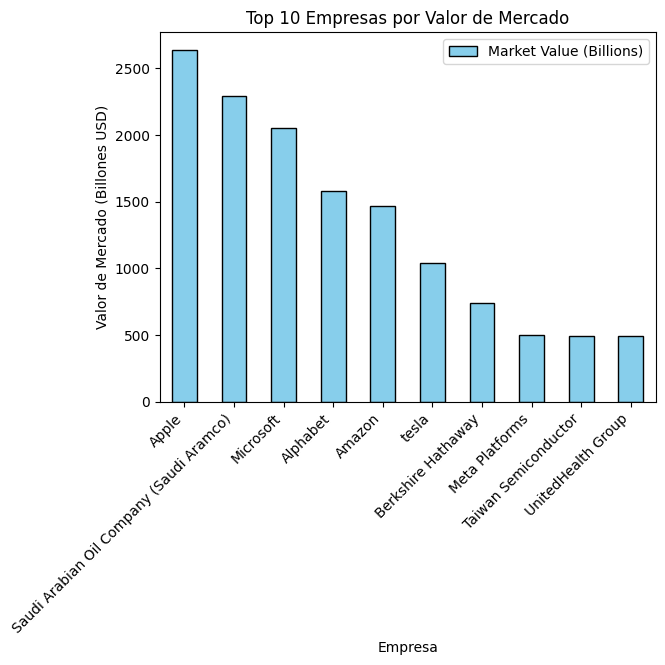

In [ ]:
# Seleccionamos las 10 empresas con mayor valor de mercado
top_empresas = info_comp.nlargest(10, 'Market Value (Billions)')

# Creamos la gráfica de barras
top_empresas.plot(
    kind='bar',
    x='Organization Name',
    y='Market Value (Billions)',
    color='skyblue',
    edgecolor='black'
)
plt.title('Top 10 Empresas por Valor de Mercado')
plt.xlabel('Empresa')
plt.ylabel('Valor de Mercado (Billones USD)')
plt.xticks(rotation=45, ha='right')
plt.show()

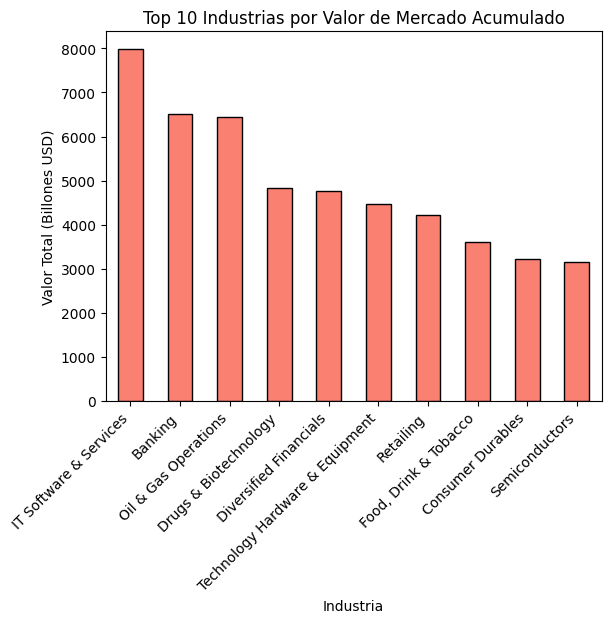

In [ ]:
# Agrupamos por industria y sumamos su valor de mercado, tomando las 10 principales
mercado_industria = (
    info_comp.groupby('Industry')['Market Value (Billions)']
    .sum()
    .nlargest(10)
)

# Gráfica
mercado_industria.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Top 10 Industrias por Valor de Mercado Acumulado')
plt.xlabel('Industria')
plt.ylabel('Valor Total (Billones USD)')
plt.xticks(rotation=45, ha='right')
plt.show()

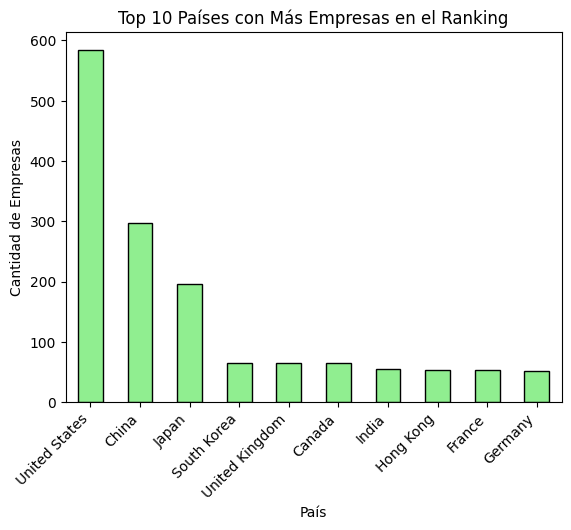

In [ ]:
# Contamos cuántas empresas hay por país y tomamos el top 10
top_paises = info_comp['Country'].value_counts().head(10)

# Gráfica
top_paises.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Top 10 Países con Más Empresas en el Ranking')
plt.xlabel('País')
plt.ylabel('Cantidad de Empresas')
plt.xticks(rotation=45, ha='right')
plt.show()

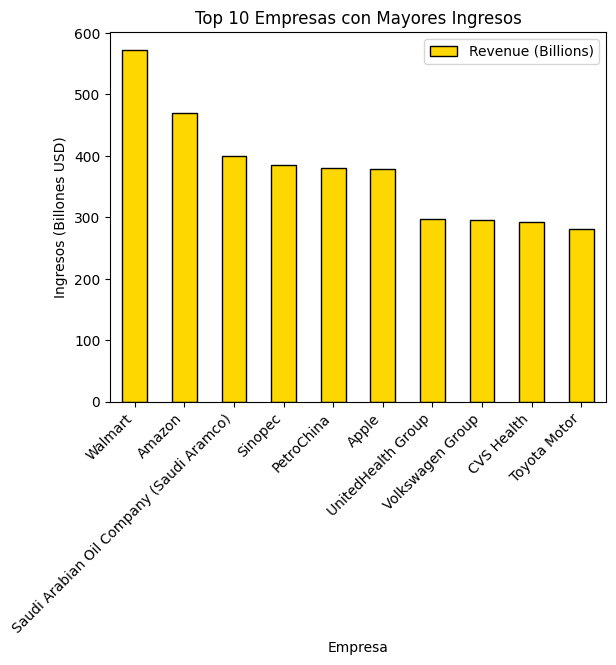

In [ ]:
# Top 10 por ingresos
top_ingresos = info_comp.nlargest(10, 'Revenue (Billions)')

# Gráfica
top_ingresos.plot(
    kind='bar',
    x='Organization Name',
    y='Revenue (Billions)',
    color='gold',
    edgecolor='black'
)
plt.title('Top 10 Empresas con Mayores Ingresos')
plt.xlabel('Empresa')
plt.ylabel('Ingresos (Billones USD)')
plt.xticks(rotation=45, ha='right')
plt.show()

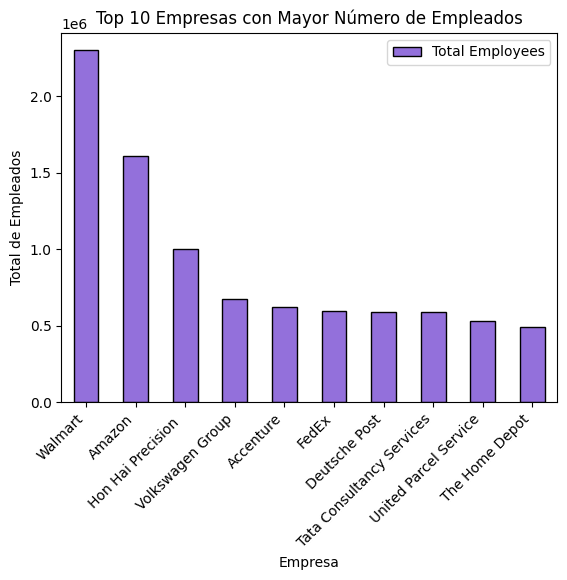

In [ ]:
# Top 10 por número de empleados
top_empleados = info_comp.nlargest(10, 'Total Employees')

# Gráfica
top_empleados.plot(
    kind='bar',
    x='Organization Name',
    y='Total Employees',
    color='mediumpurple',
    edgecolor='black'
)
plt.title('Top 10 Empresas con Mayor Número de Empleados')
plt.xlabel('Empresa')
plt.ylabel('Total de Empleados')
plt.xticks(rotation=45, ha='right')
plt.show()

## **Grafica BoxPlot**

{'whiskers': [<matplotlib.lines.Line2D at 0x7ecbb071fed0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ecbb073c190>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ecbb071fd90>],
 'medians': [<matplotlib.lines.Line2D at 0x7ecbb073c410>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ecbb073c550>],
 'means': []}

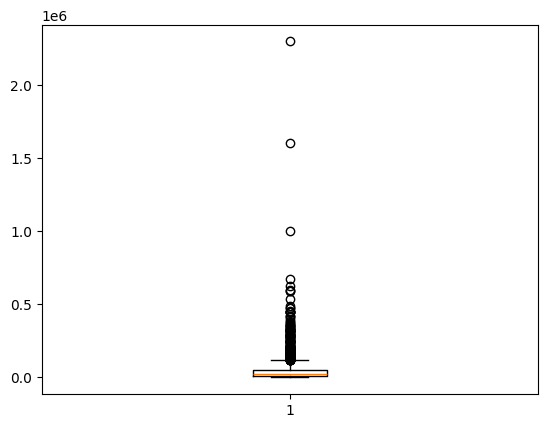

In [ ]:
#Grafica boxplot con Matplotlib
plt.boxplot(info_comp['Total Employees'])

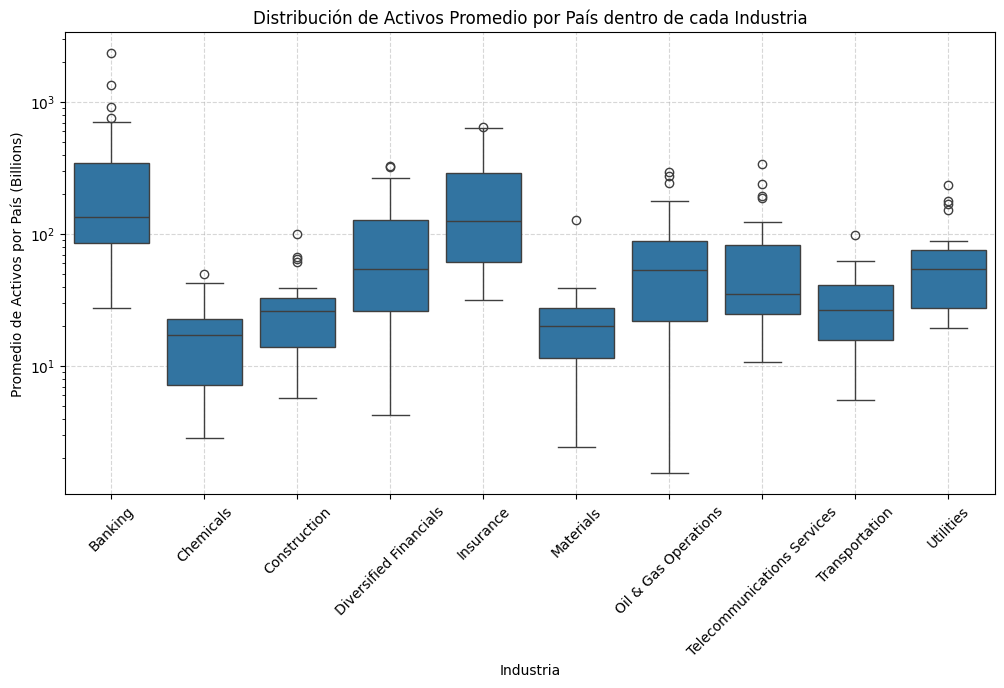

In [ ]:
# 1. CREA TABLA AGRUPADA
tabla_agrupada = info_comp[['Assets (Billions)', 'Industry', 'Country']].groupby(['Industry', 'Country']).mean().reset_index()

# 2. SELECCIONA LAS 10 INDUSTRIAS PRINCIPALES
top_industrias = tabla_agrupada['Industry'].value_counts().head(10).index
df_grafica = tabla_agrupada[tabla_agrupada['Industry'].isin(top_industrias)]

# 3. GRAFICA
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_grafica, x='Industry', y='Assets (Billions)')

plt.title('Distribución de Activos Promedio por País dentro de cada Industria')
plt.xlabel('Industria')
plt.ylabel('Promedio de Activos por País (Billions)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.yscale('log')
plt.show()

## **Grafica de Dispercion**

In [ ]:
print(info_comp['Market Value (Billions)'].mean().round(2))
print(info_comp['Assets (Billions)'].mean().round(2))

38.26
117.18


Text(0, 0.5, 'Activos en el Mercado')

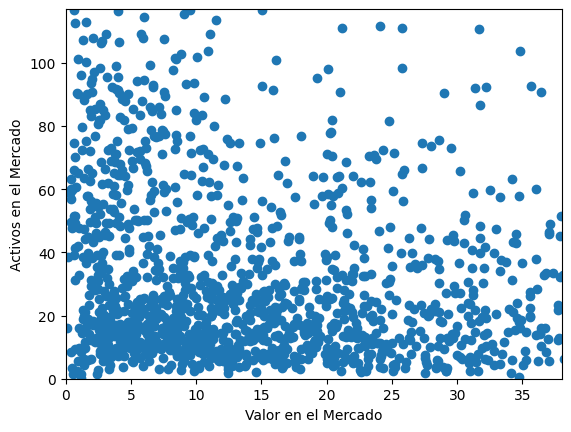

In [ ]:
#Grafica de dispersion con Matplotlib
activos = info_comp['Assets (Billions)']
valor_mercado = info_comp['Market Value (Billions)']
plt.scatter(valor_mercado, activos)
plt.xlim(0, 38)
plt.ylim(0, 117)
plt.xlabel('Valor en el Mercado')
plt.ylabel('Activos en el Mercado')


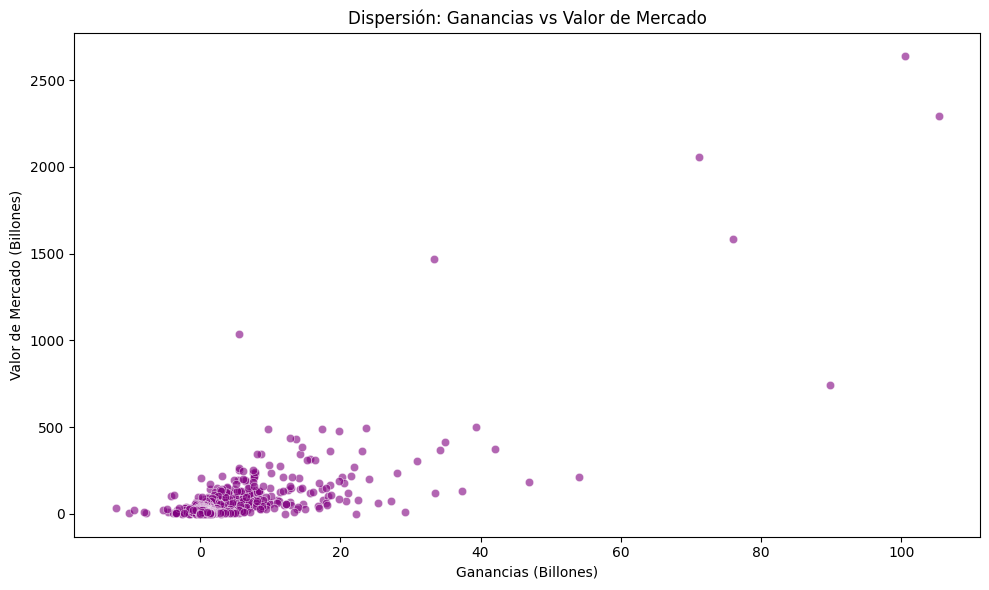

In [ ]:
# 1. Diagrama de dispersión de Ganancias vs Valor de Mercado
plt.figure(figsize=(10, 6))
sns.scatterplot(data=info_comp, x='Profits (Billions)', y='Market Value (Billions)', alpha=0.6, color='purple')
plt.title('Dispersión: Ganancias vs Valor de Mercado')
plt.xlabel('Ganancias (Billones)')
plt.ylabel('Valor de Mercado (Billones)')
plt.tight_layout()
plt.show()

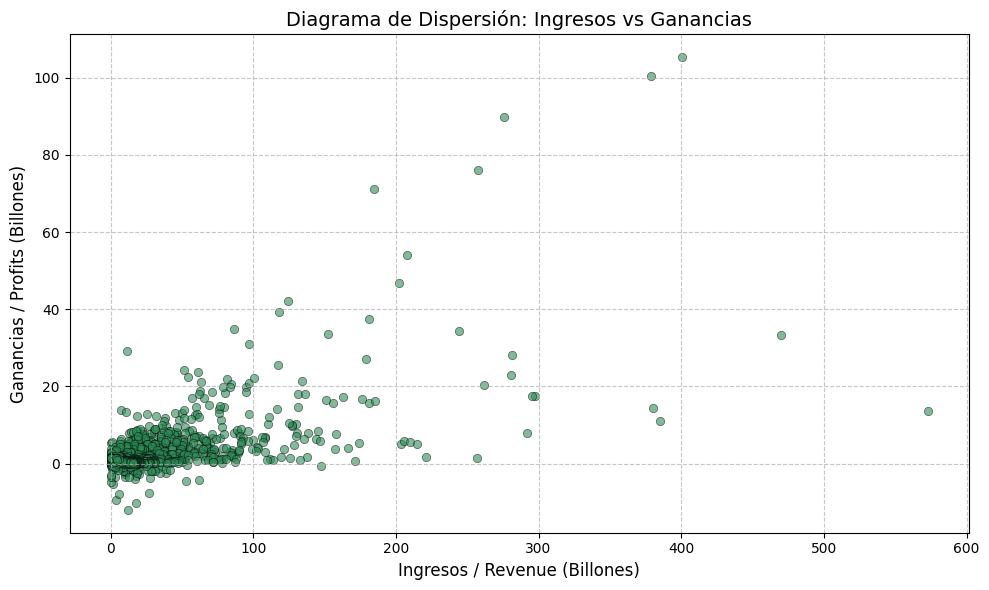

In [ ]:
# 2. Diagrama de dispersión de Ingresos vs Ganancias

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=info_comp,
    x='Revenue (Billions)',
    y='Profits (Billions)',
    alpha=0.6,
    color='seagreen',
    edgecolor='black'
)

plt.title('Diagrama de Dispersión: Ingresos vs Ganancias', fontsize=14)
plt.xlabel('Ingresos / Revenue (Billones)', fontsize=12)
plt.ylabel('Ganancias / Profits (Billones)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Grafica de Calor**

<Axes: >

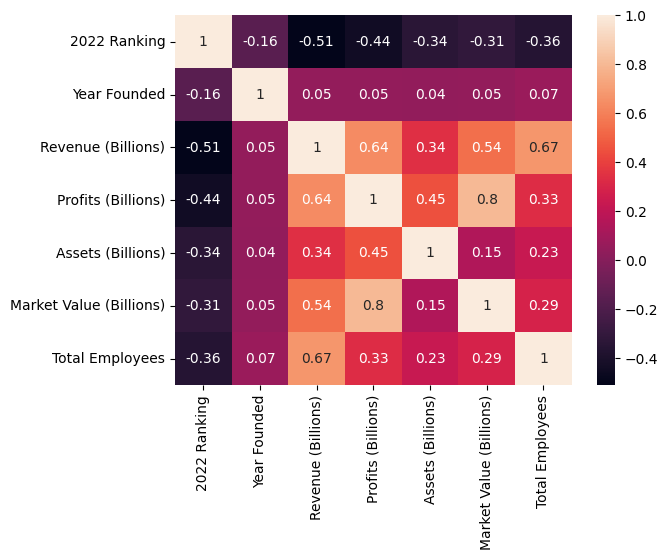

In [ ]:
# Grafica de calor con pandas
sns.heatmap(round(info_comp.corr(numeric_only=True),2), annot=True)

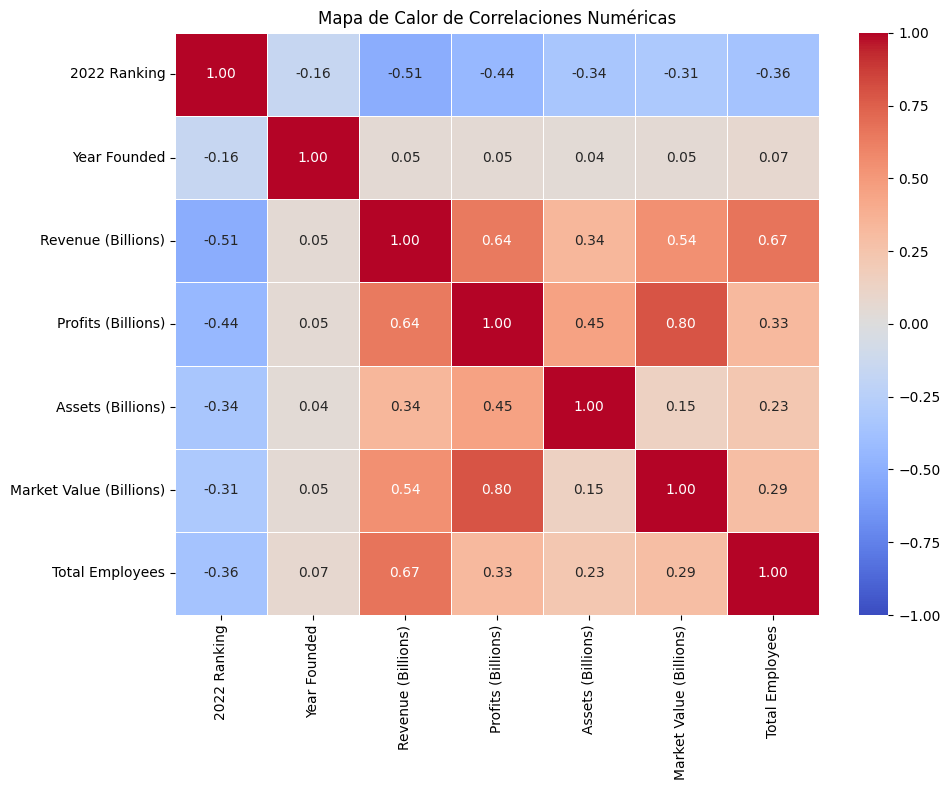

In [ ]:
# 4. Mapa de calor (Correlación entre columnas numéricas)
plt.figure(figsize=(10, 8))
correlacion = info_comp.corr(numeric_only=True)
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.tight_layout()
plt.show()